# 20 — Functional Logistic Regression: results & β(λ) analysis

Loads outputs from **`19_functional_logreg.py`** (`results/functional_logreg/`).

**Sections:**
1. Summary tables (L2 ridge vs L1 lasso)
2. β(λ) discrimination curves — the key interpretability output
3. β(λ) overlaid with mean spectral difference
4. L1 sparsity analysis
5. Per-fold metric distributions
6. Cross-experiment comparison with polynomial / FPCA / ROCKET baselines

**Run first:** `python 19_functional_logreg.py` (from `transformation_experiment/`)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as _stats

EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
DATA_DIR = EXPERIMENT_DIR / "data"
RESULTS_DIR = EXPERIMENT_DIR / "results"
FLOGREG_DIR = RESULTS_DIR / "functional_logreg"
POC_DIR = Path("transformation_poc") if Path("transformation_poc").exists() else Path("..") / "transformation_poc"

# Load wavelength grid
df_spec = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv", nrows=1)
wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]
wavelengths = np.array([float(c.split("_")[1]) for c in wl_cols], dtype=np.float64)

print(f"Results dir: {FLOGREG_DIR.resolve()}")
print(f"Wavelength grid: {len(wavelengths)} bins, {wavelengths[0]:.0f}–{wavelengths[-1]:.0f} nm")

Results dir: /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/functional_logreg
Wavelength grid: 343 bins, 336–1020 nm


## 1. Summary tables

In [2]:
df = pd.read_csv(FLOGREG_DIR / "functional_logreg_results.csv")
print(f"Loaded {len(df)} rows ({df['penalty_name'].nunique()} penalties × {df['split'].nunique()} folds)")

metric_cols = ["roc_auc", "pr_auc", "f1", "sensitivity", "specificity",
               "precision", "youden_j", "best_cv_roc_auc"]

summary_rows = []
for pname in df["penalty_name"].unique():
    sub = df[df["penalty_name"] == pname]
    row = {"penalty": pname, "n_folds": len(sub)}
    for col in metric_cols:
        row[f"{col}_mean"] = sub[col].mean()
        row[f"{col}_std"] = sub[col].std()
    if "n_nonzero_coefs" in sub.columns:
        row["n_nonzero_mean"] = sub["n_nonzero_coefs"].mean()
        row["n_nonzero_std"] = sub["n_nonzero_coefs"].std()
    summary_rows.append(row)

df_sum = pd.DataFrame(summary_rows)

# Display formatted
for _, r in df_sum.iterrows():
    print(f"\n{r['penalty']}  (n={int(r['n_folds'])} folds)")
    for col in metric_cols:
        print(f"  {col:20s}: {r[f'{col}_mean']:.4f} ± {r[f'{col}_std']:.4f}")
    if "n_nonzero_mean" in r:
        print(f"  {'n_nonzero_coefs':20s}: {r['n_nonzero_mean']:.1f} ± {r['n_nonzero_std']:.1f}")

Loaded 100 rows (2 penalties × 50 folds)

L2_ridge  (n=50 folds)
  roc_auc             : 0.9141 ± 0.0201
  pr_auc              : 0.8620 ± 0.0288
  f1                  : 0.8059 ± 0.0298
  sensitivity         : 0.8297 ± 0.0325
  specificity         : 0.9432 ± 0.0121
  precision           : 0.7843 ± 0.0380
  youden_j            : 0.7729 ± 0.0373
  best_cv_roc_auc     : 0.9157 ± 0.0058
  n_nonzero_coefs     : 343.0 ± 0.0

L1_lasso  (n=50 folds)
  roc_auc             : 0.9112 ± 0.0199
  pr_auc              : 0.8535 ± 0.0302
  f1                  : 0.7944 ± 0.0327
  sensitivity         : 0.8317 ± 0.0308
  specificity         : 0.9347 ± 0.0185
  precision           : 0.7622 ± 0.0515
  youden_j            : 0.7664 ± 0.0352
  best_cv_roc_auc     : 0.9142 ± 0.0065
  n_nonzero_coefs     : 85.0 ± 47.4


## 2. β(λ) discrimination curves — the key output

The weight function β(λ) shows which wavelength regions drive the binary/single classification.

- **L2 (ridge):** smooth curve — expected positive signal in 700–1020 nm (companion red flux excess)
- **L1 (lasso):** sparse curve — nonzero weights concentrated in the most discriminative wavelengths

L2 betas: (5, 343), L1 betas: (5, 343)


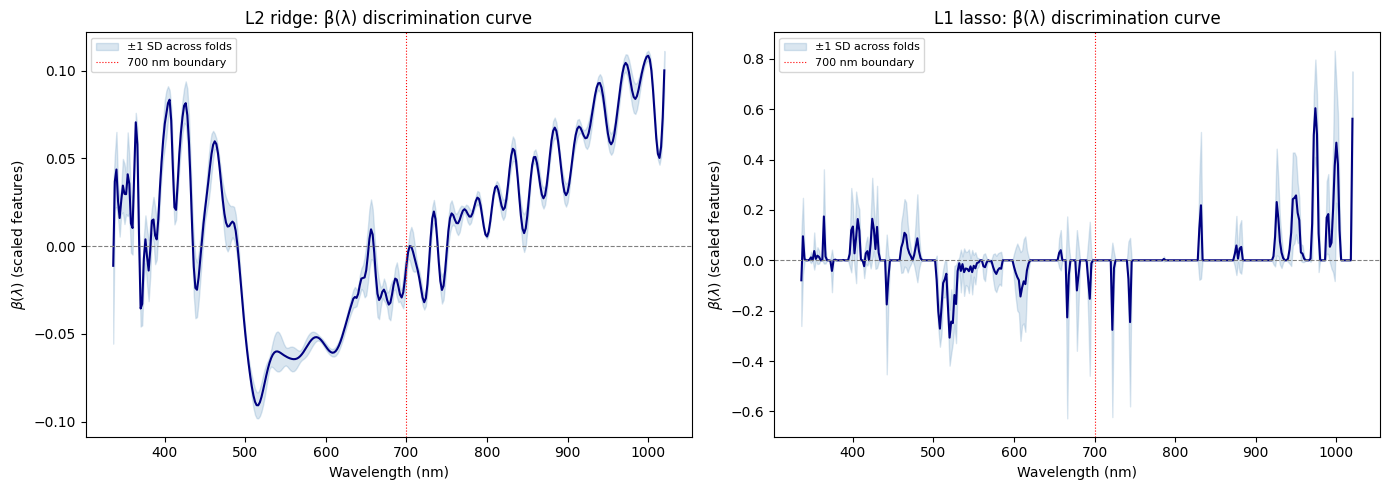

In [3]:
beta_l2 = np.load(FLOGREG_DIR / "beta_vectors_L2_ridge.npy")
beta_l1 = np.load(FLOGREG_DIR / "beta_vectors_L1_lasso.npy")
print(f"L2 betas: {beta_l2.shape}, L1 betas: {beta_l1.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, betas, title in [
    (axes[0], beta_l2, "L2 ridge: β(λ) discrimination curve"),
    (axes[1], beta_l1, "L1 lasso: β(λ) discrimination curve"),
]:
    m = betas.mean(axis=0)
    s = betas.std(axis=0)
    ax.plot(wavelengths, m, color="navy", lw=1.5)
    ax.fill_between(wavelengths, m - s, m + s, alpha=0.2, color="steelblue",
                    label="±1 SD across folds")
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.axvline(700, color="red", ls=":", lw=0.8, label="700 nm boundary")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(r"$\beta(\lambda)$ (scaled features)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.show()

## 3. β(λ) overlaid with mean spectral difference

Shows whether β(λ) traces the same wavelength regions as the raw mean spectrum difference (binary − single). If they align, the linear model captures the dominant signal.

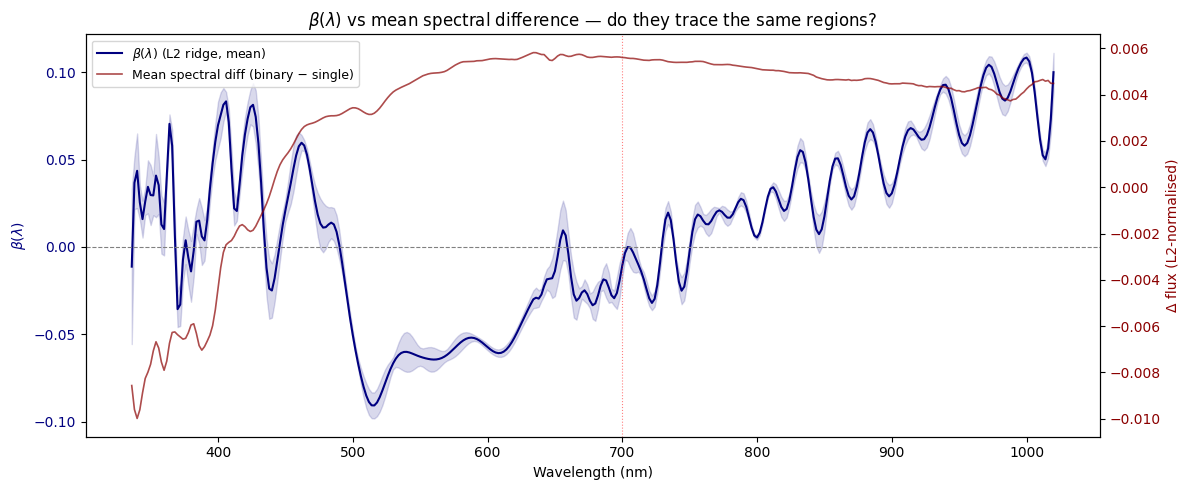

In [4]:
# Load L2-normalised spectra for mean difference
df_og = pd.read_csv(DATA_DIR / "og_xp.csv")
df_spec_full = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv")
df_m = df_og[["source_id", "y"]].merge(
    df_spec_full[["source_id"] + wl_cols], on="source_id", how="inner"
)
y = df_m["y"].to_numpy()
F_raw = df_m[wl_cols].to_numpy(dtype=np.float64)
row_norm = np.linalg.norm(F_raw, axis=1, keepdims=True)
F = np.divide(F_raw, row_norm, out=np.zeros_like(F_raw), where=row_norm > 1e-20)

delta = F[y == 1].mean(axis=0) - F[y == 0].mean(axis=0)
beta_l2_mean = beta_l2.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = "navy"
ax1.plot(wavelengths, beta_l2_mean, color=color1, lw=1.5, label=r"$\beta(\lambda)$ (L2 ridge, mean)")
ax1.fill_between(wavelengths,
                 beta_l2_mean - beta_l2.std(axis=0),
                 beta_l2_mean + beta_l2.std(axis=0),
                 alpha=0.15, color=color1)
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel(r"$\beta(\lambda)$", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "darkred"
ax2.plot(wavelengths, delta, color=color2, lw=1.2, alpha=0.7,
         label="Mean spectral diff (binary − single)")
ax2.set_ylabel("Δ flux (L2-normalised)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.axhline(0, color="gray", ls="--", lw=0.8)
ax1.axvline(700, color="red", ls=":", lw=0.8, alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title(r"$\beta(\lambda)$ vs mean spectral difference — do they trace the same regions?")
fig.tight_layout()
plt.show()

## 4. L1 sparsity analysis

How many wavelength bins have nonzero β(λ) under L1 regularisation? Cross-fold stability of nonzero positions.

Nonzero coefficients per fold: 64.6 ± 28.0 (min=40, max=105) out of 343
Best C per fold: median=0.3594, range=[0.04642, 1e+04]


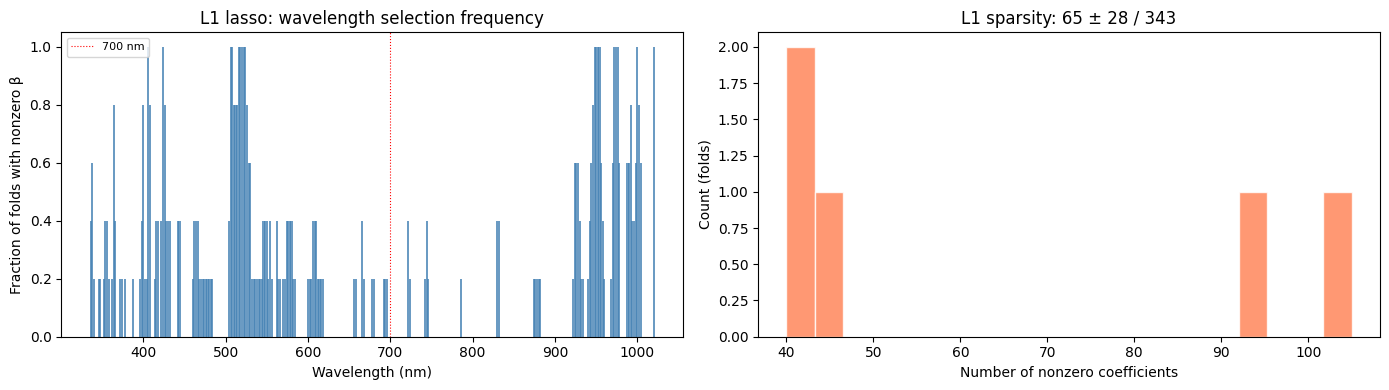

In [5]:
L1_TOL = 1e-6
nonzero_mask = np.abs(beta_l1) > L1_TOL  # (n_folds, 343)
n_nonzero_per_fold = nonzero_mask.sum(axis=1)
freq_nonzero = nonzero_mask.mean(axis=0)  # fraction of folds where each bin is nonzero

print(f"Nonzero coefficients per fold: {n_nonzero_per_fold.mean():.1f} ± {n_nonzero_per_fold.std():.1f} "
      f"(min={n_nonzero_per_fold.min()}, max={n_nonzero_per_fold.max()}) out of {beta_l1.shape[1]}")

# From results CSV
l1_sub = df[df["penalty_name"] == "L1_lasso"]
print(f"Best C per fold: median={l1_sub['best_C'].median():.4g}, "
      f"range=[{l1_sub['best_C'].min():.4g}, {l1_sub['best_C'].max():.4g}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: nonzero frequency by wavelength
ax = axes[0]
ax.bar(wavelengths, freq_nonzero, width=2.5, color="steelblue", alpha=0.8)
ax.axvline(700, color="red", ls=":", lw=0.8, label="700 nm")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Fraction of folds with nonzero β")
ax.set_title("L1 lasso: wavelength selection frequency")
ax.legend(fontsize=8)

# Right: histogram of nonzero count per fold
ax = axes[1]
ax.hist(n_nonzero_per_fold, bins=20, color="coral", edgecolor="white", alpha=0.8)
ax.set_xlabel("Number of nonzero coefficients")
ax.set_ylabel("Count (folds)")
ax.set_title(f"L1 sparsity: {n_nonzero_per_fold.mean():.0f} ± {n_nonzero_per_fold.std():.0f} / {beta_l1.shape[1]}")

fig.tight_layout()
plt.show()

## 5. Per-fold metric distributions

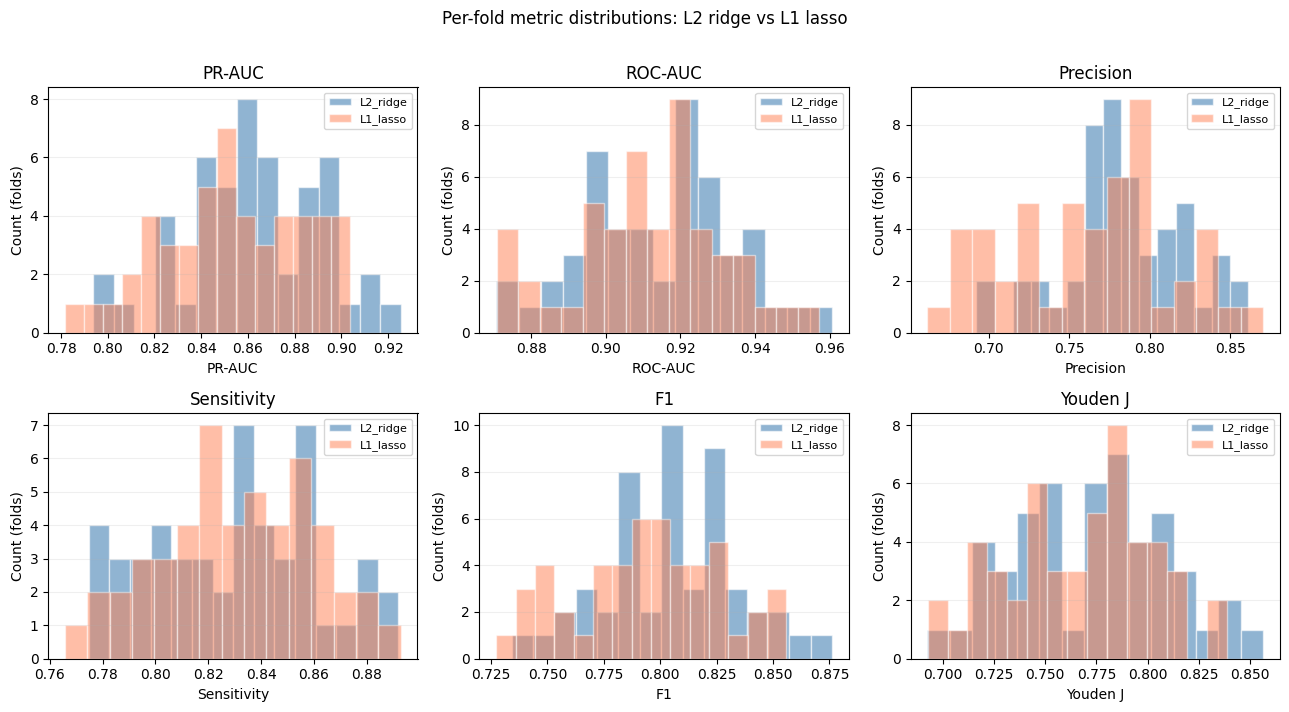

In [6]:
hist_metrics = [
    ("pr_auc", "PR-AUC"),
    ("roc_auc", "ROC-AUC"),
    ("precision", "Precision"),
    ("sensitivity", "Sensitivity"),
    ("f1", "F1"),
    ("youden_j", "Youden J"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for ax, (col, label) in zip(axes, hist_metrics):
    for pname, color, alpha in [("L2_ridge", "steelblue", 0.6), ("L1_lasso", "coral", 0.5)]:
        sub = df[df["penalty_name"] == pname]
        ax.hist(sub[col].dropna(), bins=15, color=color, edgecolor="white",
                alpha=alpha, label=pname)
    ax.set_xlabel(label)
    ax.set_ylabel("Count (folds)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis="y")

fig.suptitle("Per-fold metric distributions: L2 ridge vs L1 lasso", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 6. Cross-experiment comparison

Compare functional LR against polynomial baselines (from `focused_summary.csv`), FPCA, and ROCKET.

In [7]:
def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

comp_rows = []

# Functional LR (this experiment)
for pname in ["L2_ridge", "L1_lasso"]:
    sub = df[df["penalty_name"] == pname]
    comp_rows.append({
        "Method": f"Functional LR ({pname})",
        "Representation": "343-d L2 spectra",
        "K/dim": 343,
        "PR-AUC": fmt(sub["pr_auc"].mean(), sub["pr_auc"].std()),
        "ROC-AUC": fmt(sub["roc_auc"].mean(), sub["roc_auc"].std()),
        "F1": fmt(sub["f1"].mean(), sub["f1"].std()),
        "Sensitivity": fmt(sub["sensitivity"].mean(), sub["sensitivity"].std()),
        "Precision": fmt(sub["precision"].mean(), sub["precision"].std()),
    })

# Polynomial baselines (focused experiment)
if (RESULTS_DIR / "focused_summary.csv").exists():
    df_base = pd.read_csv(RESULTS_DIR / "focused_summary.csv")

    def best_svm(mask):
        return df_base.loc[mask].sort_values("pr_auc_mean", ascending=False).iloc[0]

    # XP 110
    r = best_svm((df_base["representation"] == "og_xp_110") & (df_base["classifier"] == "SVM_RBF"))
    comp_rows.append({
        "Method": "XP 110-d + SVM RBF",
        "Representation": "Native Hermite coeffs",
        "K/dim": 110,
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
    })

    # Best Chebyshev
    ch_mask = (df_base["representation"].str.startswith("chebyshev")
               & df_base["representation"].str.endswith("_L2")
               & (df_base["classifier"] == "SVM_RBF"))
    r = best_svm(ch_mask)
    comp_rows.append({
        "Method": f"Chebyshev L2 + SVM",
        "Representation": "Polynomial coeffs",
        "K/dim": int(r["n_features"]),
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
    })

    # Best Chebyshev + LogReg (direct comparison with functional LR)
    ch_lr_mask = (df_base["representation"].str.startswith("chebyshev")
                  & df_base["representation"].str.endswith("_L2")
                  & (df_base["classifier"] == "LogisticRegression"))
    if ch_lr_mask.any():
        r = best_svm(ch_lr_mask)
        comp_rows.append({
            "Method": f"Chebyshev L2 + LogReg",
            "Representation": "Polynomial coeffs",
            "K/dim": int(r["n_features"]),
            "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
            "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
            "F1": fmt(r["f1_mean"], r["f1_std"]),
            "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
            "Precision": fmt(r["precision_mean"], r["precision_std"]),
        })

# FPCA best
if (RESULTS_DIR / "fpca_classifier_summary.csv").exists():
    df_fpca = pd.read_csv(RESULTS_DIR / "fpca_classifier_summary.csv")
    r = df_fpca.loc[df_fpca["pr_auc_mean"].idxmax()]
    comp_rows.append({
        "Method": f"FPCA + {r['classifier'].upper()}",
        "Representation": "Data-adaptive (SVD)",
        "K/dim": int(r["J"]),
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
    })

# ROCKET best
if (RESULTS_DIR / "rocket_rskf_summary.csv").exists():
    df_rocket = pd.read_csv(RESULTS_DIR / "rocket_rskf_summary.csv")
    r = df_rocket.loc[df_rocket["pr_auc_mean"].idxmax()]
    method_label = r.get("method", "rocket")
    clf_label = r.get("classifier", "ridge")
    comp_rows.append({
        "Method": f"{method_label} + {clf_label}",
        "Representation": "Random convolutions",
        "K/dim": int(r["n_kernels"]) if "n_kernels" in r.index else "—",
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
    })

df_comp = pd.DataFrame(comp_rows)
display(df_comp)

,Method,Representation,K/dim,PR-AUC,ROC-AUC,F1,Sensitivity,Precision
0,Functional LR (L2_ridge),343-d L2 spectra,343,0.8620 ± 0.0288,0.9141 ± 0.0201,0.8059 ± 0.0298,0.8297 ± 0.0325,0.7843 ± 0.0380
1,Functional LR (L1_lasso),343-d L2 spectra,343,0.8535 ± 0.0302,0.9112 ± 0.0199,0.7944 ± 0.0327,0.8317 ± 0.0308,0.7622 ± 0.0515
2,XP 110-d + SVM RBF,Native Hermite coeffs,110,0.8805 ± 0.0038,0.9386 ± 0.0017,0.7995 ± 0.0088,0.8419 ± 0.0131,0.7631 ± 0.0223
3,Chebyshev L2 + SVM,Polynomial coeffs,5,0.8750 ± 0.0047,0.9274 ± 0.0016,0.8112 ± 0.0056,0.8335 ± 0.0049,0.7915 ± 0.0105
4,Chebyshev L2 + LogReg,Polynomial coeffs,10,0.8616 ± 0.0016,0.9203 ± 0.0015,0.8215 ± 0.0064,0.8330 ± 0.0033,0.8113 ± 0.0123
5,FPCA + SVM,Data-adaptive (SVD),30,0.6702 ± 0.0387,0.8648 ± 0.0184,0.5661 ± 0.0233,0.8692 ± 0.0343,0.4206 ± 0.0255
6,minirocket + nan,Random convolutions,10000,0.8702 ± 0.0286,0.9276 ± 0.0165,0.7795 ± 0.0353,0.8346 ± 0.0348,0.7329 ± 0.0495


## 7. β(λ) cross-fold stability

Check whether the standard deviation of β(λ) is much smaller than the mean in the signal region (700–1020 nm). Low ratio → stable estimate.

L2 ridge: |mean| / std ratio:
  Red (≥700nm): median ratio = 9.33
  Blue (<700nm): median ratio = 5.85
L1 lasso: |mean| / std ratio:
  Red (≥700nm): median ratio = 0.00
  Blue (<700nm): median ratio = 0.50


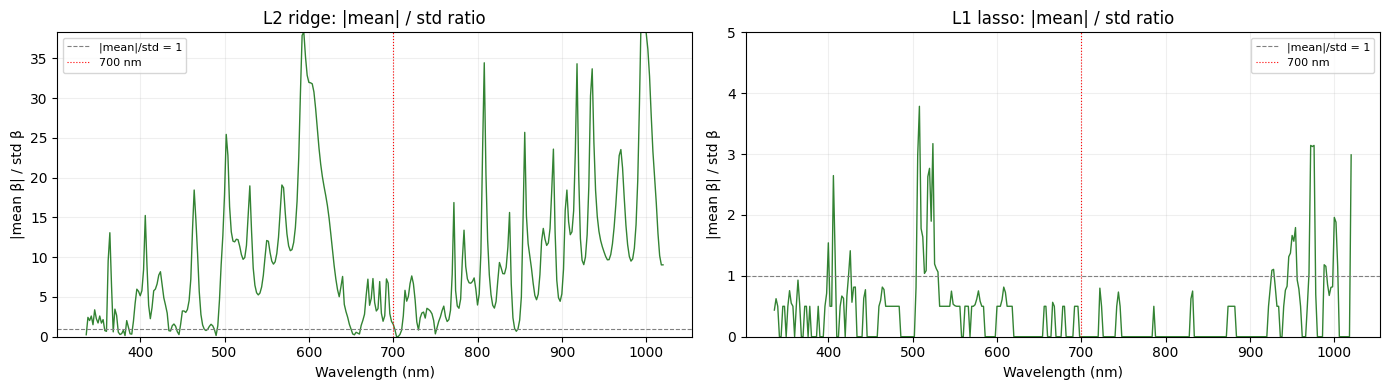

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, betas, title in [
    (axes[0], beta_l2, "L2 ridge: |mean| / std ratio"),
    (axes[1], beta_l1, "L1 lasso: |mean| / std ratio"),
]:
    m = np.abs(betas.mean(axis=0))
    s = betas.std(axis=0)
    ratio = np.divide(m, s, out=np.zeros_like(m), where=s > 1e-10)

    ax.plot(wavelengths, ratio, color="darkgreen", lw=1.0, alpha=0.8)
    ax.axhline(1, color="gray", ls="--", lw=0.8, label="|mean|/std = 1")
    ax.axvline(700, color="red", ls=":", lw=0.8, label="700 nm")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("|mean β| / std β")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(5, np.percentile(ratio[ratio > 0], 99)))
    ax.grid(True, alpha=0.2)

    # Summary stats for signal region
    red_mask = wavelengths >= 700
    blue_mask = wavelengths < 700
    print(f"{title}:")
    print(f"  Red (≥700nm): median ratio = {np.median(ratio[red_mask]):.2f}")
    print(f"  Blue (<700nm): median ratio = {np.median(ratio[blue_mask]):.2f}")

fig.tight_layout()
plt.show()